# Task 15: Implementing Agent Based Modeling

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Defining helper functions for the simulation

In [2]:
class Person:
    def __init__(self, state, position, speed, extremes):
        self.state, self.position = state, position
        self.speed, self.extremes = speed, extremes
        angle = np.random.uniform(0, 2*np.pi)
        self.xy_dir = [np.cos(angle), np.sin(angle)]
        self.rehabilitation = 0

    def step_ahead(self, community, min_contact_radius, dead_p, limit_infected_friends):
        self = contacts(self, community, min_contact_radius, dead_p, limit_infected_friends)
        self = new_pos(self)


def contacts(person, community, min_contact_radius, dead_p, limit_infected_friends):
    if person.state == 'Susceptible':
        close_people = 0
        for friend in community:
            xx = (person.position[0]-friend.position[0])
            yy = (person.position[1]-friend.position[1])
            if (friend.state == 'Infected') and ((np.sqrt(xx**2 + yy**2) < min_contact_radius)):
                close_people += 1
        prob = 1 if close_people/limit_infected_friends > 1 else close_people/limit_infected_friends
        if np.random.choice(['Susceptible', 'Infected'], 1, p=[1-prob, prob])[0] == 'Infected':
            person.state = 'Infected'
    elif person.state == 'Infected':
        if np.random.choice(['Infected', 'Dead'], 1, p=[1-dead_p, dead_p])[0] == 'Infected':
            person.rehabilitation += 1
            if person.rehabilitation >= 7:
                person.state = 'Recovered'
        else:
            person.state = 'Dead'
    return person


def new_pos(person):
    for i in [0, 1]:
        if person.position[i] + person.xy_dir[i]*person.speed < person.extremes[0]:
            person.position[i] = -person.position[i] - person.xy_dir[i]*person.speed + 2*person.extremes[0]
            person.xy_dir[i] = -person.xy_dir[i] 
        elif person.position[i] + person.xy_dir[i]*person.speed > person.extremes[1]:
            person.position[i] = -person.position[i] - person.xy_dir[i]*person.speed + 2*person.extremes[1]
            person.xy_dir[i] = -person.xy_dir[i] 
        else:
            person.position[i] = person.position[i] + person.xy_dir[i]*person.speed
            person.xy_dir[i] = person.xy_dir[i]
    return person

## Main simulation function

In [3]:
def population_sim(pop_size, iterations, prob_infected,
                   grid_limits, min_contact_radius,
                   dead_p, limit_infected_friends):
    population = []
    for grid_l in grid_limits:
        for i in range(0, pop_size//len(grid_limits)):
            population.append(Person(np.random.choice(['Susceptible', 'Infected'], 1, 
                                                      p=[1-prob_infected, prob_infected])[0],
                                     [np.random.uniform(grid_l[0], grid_l[1]),
                                      np.random.uniform(grid_l[0], grid_l[1])],
                                      np.random.uniform(0, 1), grid_l))

    susceptible, infected, recovered, dead = [], [], [], []
    x_res, y_res = [], []
    index, state = [], []
    for it in range(iterations):
        it_susceptible, it_infected, it_recovered, it_dead = 0, 0, 0, 0
        for i, person in enumerate(population):
            x_res.append(person.position[0])
            y_res.append(person.position[1])
            index.append(it)
            if person.state == 'Susceptible':
                it_susceptible += 1
            elif person.state == 'Infected':
                it_infected += 1
            elif person.state == 'Dead':
                it_dead += 1
            else:
                it_recovered += 1
            state.append(person.state)
            person.step_ahead(population[:i]+population[i+1:], min_contact_radius,
                              dead_p, limit_infected_friends)
        susceptible.append(it_susceptible)
        infected.append(it_infected)
        recovered.append(it_recovered)
        dead.append(it_dead)

    return susceptible, infected, recovered, dead, x_res, y_res, state, index

## Running the simulation and exploring the results

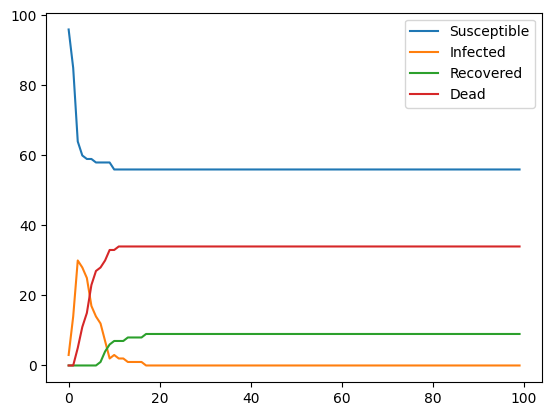

In [4]:
# Initial number of individuals in the population
pop_size = 100
# Number of iterations for the simulation
iterations = 100
# Probability to get infected if in close contact with someone infected
prob_infected = 0.04
# Size of the simulation space
grid_max = [0, 5]
# Position of the individual communities within the simulation space
grid_limits = [grid_max, [0, 1], [4, 5]]
# Radius within which someone might get infected if in contact with someone positive
min_contact_radius = 0.3
# Probability to die if infected
dead_p = 0.2
# Number of minimum infacted people with which we are in close contact above which we are 100% sure we
# are gonna get infected in the next iteration step
limit_infected_friends = 4

# x_res, y_res = x and y coordinates of each member in the population
# state = record of the health status of each individual during the simulation
# index = iteration number for each individual in each timestamp 
# (to make possible to filter spatial data frame by frame later on)
susceptible, infected, recovered, dead, x_res, y_res, state, index = population_sim(pop_size, iterations, 
                                                                                    prob_infected, 
                                                                                    grid_limits, 
                                                                                    min_contact_radius,  
                                                                                    dead_p, limit_infected_friends)

plt.plot(susceptible, label='Susceptible')
plt.plot(infected, label='Infected')
plt.plot(recovered, label='Recovered')
plt.plot(dead, label='Dead')
plt.legend()
plt.show()